In [19]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [10]:
image_path = '../output_videos/cropped_image.jpg'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

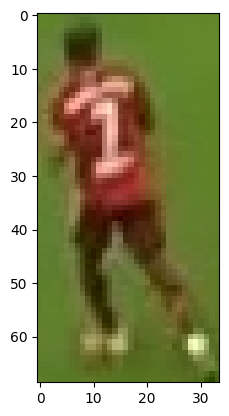

In [14]:
plt.imshow(image)
plt.show()

# Take the top half of the image

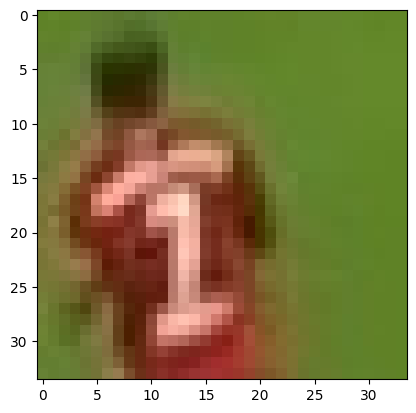

In [16]:
top_half_img = image[0 :int(image.shape[0]/2), :]
plt.imshow(top_half_img)
plt.show()

# Cluster the image into two clusters

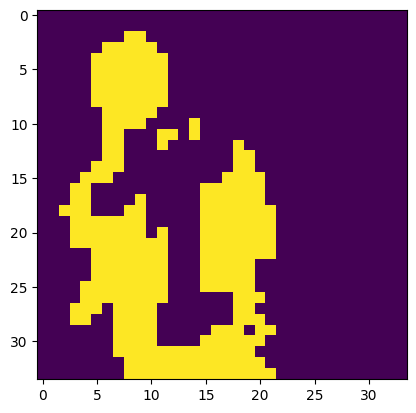

In [23]:
# Reshape the image into 2d array
image_2d = top_half_img.reshape(-1, 3)

# perform k-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

# get the cluster labels
labels = kmeans.labels_

# reshape the labels into the original image shape
clustered_image = labels.reshape(top_half_img.shape[0], top_half_img.shape[1])

# Display the clustered image
plt.imshow(clustered_image)
plt.show()

In [30]:
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster)

0


In [31]:
player_cluster = 1 - non_player_cluster
print(player_cluster)

1


In [32]:
kmeans.cluster_centers_[player_cluster]

array([107.57931034,  56.57586207,  27.46896552])